# Decode deconvolved calcium with `SortedSpikesDecoder`

This notebook mirrors the sorted-spikes tutorial workflow, but replaces ground-truth spike trains with OASIS-deconvolved calcium spikes.

It covers three cases:

1. **Baseline decode**: fit on run A, decode run B, and decode a continuous replay event.
2. **Noise effect**: visualize decoding at `sigma = 1.0, 4.0, 8.0`, then sweep sigma values and measure median absolute decoding error.
3. **Speed effect**: compare run decoding at three running speeds.


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from replay_trajectory_classification.calcium_sorted_spikes_decoding import (
    deconvolve_and_binarize,
    make_sorted_spikes_decoder,
    maximum_a_posteriori_position,
    median_decoding_error,
)
from replay_trajectory_classification.simulate import simulate_position, simulate_time
from replay_trajectory_classification.simulate_calcium import (
    make_continuous_replay,
    make_simulated_run_data,
)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
sns.set_context("talk", font_scale=0.8)
np.random.seed(0)

In [8]:
TRACK_HEIGHT = 120.0
N_NEURONS = 12
PLACE_FIELD_MEANS = np.linspace(0.0, TRACK_HEIGHT, N_NEURONS)
RUN_SAMPLING_FREQUENCY = 30
REPLAY_SAMPLING_FREQUENCY = 200
INTERNAL_SAMPLING_FREQUENCY = 1000
N_RUNS = 2
BASE_SIGMA = 1.0
BASE_RUNNING_SPEED = 10.0
REPLAY_SPEEDUP = 120
POSITION_STD = 3.0
FIXED_SIGMAS = [1.0, 4.0, 8.0]
SIGMA_SWEEP = np.array([1.0, 2.0, 4.0, 8.0, 10.0, 12.0, 14.0, 16.0, 18.0, 20.0])
SPEED_VALUES = [5.0, 30.0, 60.0, 90.0, 120.0]

In [9]:
def make_run_dataset(rng_seed, sigma=BASE_SIGMA, running_speed=BASE_RUNNING_SPEED):
    time, position, sampling_frequency, calcium_traces, true_spikes, place_fields = make_simulated_run_data(
        sampling_frequency=RUN_SAMPLING_FREQUENCY,
        track_height=TRACK_HEIGHT,
        running_speed=running_speed,
        n_runs=N_RUNS,
        place_field_means=PLACE_FIELD_MEANS,
        sigma=sigma,
        rng=np.random.default_rng(rng_seed),
    )
    inferred_spikes = deconvolve_and_binarize(calcium_traces)
    return {
        "time": time,
        "position": position,
        "sampling_frequency": sampling_frequency,
        "calcium_traces": calcium_traces,
        "true_spikes": true_spikes,
        "inferred_spikes": inferred_spikes,
        "place_fields": place_fields,
        "sigma": sigma,
        "running_speed": running_speed,
    }


def make_true_continuous_replay_position(
    replay_time,
    track_height=TRACK_HEIGHT,
    running_speed=BASE_RUNNING_SPEED,
    replay_speedup=REPLAY_SPEEDUP,
    is_outbound=True,
):
    replay_time = np.asarray(replay_time, dtype=float)
    replay_speed = running_speed * replay_speedup
    if is_outbound:
        return np.minimum(replay_speed * replay_time, track_height)
    return np.maximum(track_height - replay_speed * replay_time, 0.0)


def make_replay_dataset(rng_seed, sigma=BASE_SIGMA, running_speed=BASE_RUNNING_SPEED):
    time, true_spikes, calcium_traces = make_continuous_replay(
        sampling_frequency=REPLAY_SAMPLING_FREQUENCY,
        internal_sampling_frequency=INTERNAL_SAMPLING_FREQUENCY,
        track_height=TRACK_HEIGHT,
        running_speed=running_speed,
        place_field_means=PLACE_FIELD_MEANS,
        replay_speedup=REPLAY_SPEEDUP,
        sigma=sigma,
        rng=np.random.default_rng(rng_seed),
    )
    true_position = make_true_continuous_replay_position(time, running_speed=running_speed)
    assert true_position.shape == time.shape, "Replay position must align with replay time bins"
    inferred_spikes = deconvolve_and_binarize(calcium_traces)
    return {
        "time": time,
        "position": true_position,
        "sampling_frequency": REPLAY_SAMPLING_FREQUENCY,
        "calcium_traces": calcium_traces,
        "true_spikes": true_spikes,
        "inferred_spikes": inferred_spikes,
        "sigma": sigma,
        "running_speed": running_speed,
    }


def fit_decoder(run_dataset):
    decoder = make_sorted_spikes_decoder(
        position=run_dataset["position"],
        sampling_frequency=run_dataset["sampling_frequency"],
        position_std=POSITION_STD,
    )
    decoder.fit(run_dataset["position"], run_dataset["inferred_spikes"])
    return decoder


def decode_dataset(decoder, dataset):
    return decoder.predict(dataset["inferred_spikes"], time=dataset["time"])


def raster_points(spikes):
    spike_time_ind, neuron_ind = np.nonzero(spikes)
    return spike_time_ind, neuron_ind


def plot_baseline_decode(dataset, results, title):
    fig, axes = plt.subplots(3, 1, sharex=True, constrained_layout=True, figsize=(14, 7))
    spike_time_ind, neuron_ind = raster_points(dataset["inferred_spikes"])
    cmap = plt.get_cmap("tab20")
    colors = [cmap.colors[ind % len(cmap.colors)] for ind in neuron_ind]

    axes[0].scatter(dataset["time"][spike_time_ind], neuron_ind + 1, c=colors, s=5, clip_on=False)
    axes[0].set_ylabel("Cells")
    axes[0].set_yticks((1, dataset["inferred_spikes"].shape[1]))
    axes[0].set_title(title)

    results.causal_posterior.plot(
        x="time", y="position", ax=axes[1], cmap="bone_r", vmin=0.0, vmax=0.08, add_colorbar=False
    )
    axes[1].plot(dataset["time"], dataset["position"], color="magenta", linestyle="--", linewidth=2)
    axes[1].set_ylabel("Position")
    axes[1].set_xlabel("")
    axes[1].set_title("Causal posterior")

    results.acausal_posterior.plot(
        x="time", y="position", ax=axes[2], cmap="bone_r", vmin=0.0, vmax=0.08, add_colorbar=False
    )
    axes[2].plot(dataset["time"], dataset["position"], color="magenta", linestyle="--", linewidth=2)
    axes[2].set_ylabel("Position")
    axes[2].set_xlabel("Time [s]")
    axes[2].set_title("Acausal posterior")
    sns.despine(offset=5)
    return fig, axes


def plot_overlay_panel(ax, dataset, results, title, posterior_name="acausal_posterior"):
    posterior = getattr(results, posterior_name)
    posterior.plot(x="time", y="position", ax=ax, cmap="bone_r", vmin=0.0, vmax=0.08, add_colorbar=False)
    ax.plot(dataset["time"], dataset["position"], color="magenta", linestyle="--", linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Position")


def summarize_errors(rows, sort_key):
    return pd.DataFrame(rows).sort_values(sort_key).reset_index(drop=True)

## 1. Baseline decode: fit on run A, decode run B, decode continuous replay

In [10]:
run_a = make_run_dataset(rng_seed=0, sigma=BASE_SIGMA, running_speed=BASE_RUNNING_SPEED)
run_b = make_run_dataset(rng_seed=1, sigma=BASE_SIGMA, running_speed=BASE_RUNNING_SPEED)
replay_b = make_replay_dataset(rng_seed=2, sigma=BASE_SIGMA, running_speed=BASE_RUNNING_SPEED)

decoder = fit_decoder(run_a)
run_b_results = decode_dataset(decoder, run_b)
replay_b_results = decode_dataset(decoder, replay_b)

run_b_error = median_decoding_error(run_b_results.acausal_posterior, run_b["position"])
replay_b_map = maximum_a_posteriori_position(replay_b_results.acausal_posterior)

print(f"Run B median absolute error: {run_b_error:.2f} cm")
print(f"Replay B decoded position range: {replay_b_map.min():.2f} to {replay_b_map.max():.2f} cm")
run_b_results

/home/ericliu/anaconda3/lib/python3.13/site-packages/oasis/functions.py:817: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not `ravel`ed. To preserve the existing behavior and silence this warning, `ravel` arguments before passing them to `toeplitz`.
  A = scipy.linalg.toeplitz(xc[np.arange(lags)],
/home/ericliu/anaconda3/lib/python3.13/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 200, using nperseg = 200
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/home/ericliu/anaconda3/lib/python3.13/site-packages/replay_trajectory_classification/likelihoods/spiking_likelihood_kde.py:148: RuntimeWarning: divide by zero encountered in log
  return np.exp(np.log(mean_rate) + np.log(marginal_density) - np.log(occupancy))


  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

Run B median absolute error: 2.45 cm
Replay B decoded position range: 1.00 to 7.00 cm


<xarray.Dataset> Size: 2MB
Dimensions:            (time: 1454, position: 60)
Coordinates:
  * time               (time) float64 12kB 0.0 0.033 0.066 ... 47.88 47.92 47.95
  * position           (position) float64 480B 1.0 3.0 5.0 ... 115.0 117.0 119.0
Data variables:
    likelihood         (time, position) float64 698kB 0.878 0.8901 ... 3.828e-14
    causal_posterior   (time, position) float64 698kB 0.01728 ... 2.194e-95
    acausal_posterior  (time, position) float64 698kB 0.2064 ... 2.194e-95
Attributes:
    data_log_likelihood:  -574.674813853753

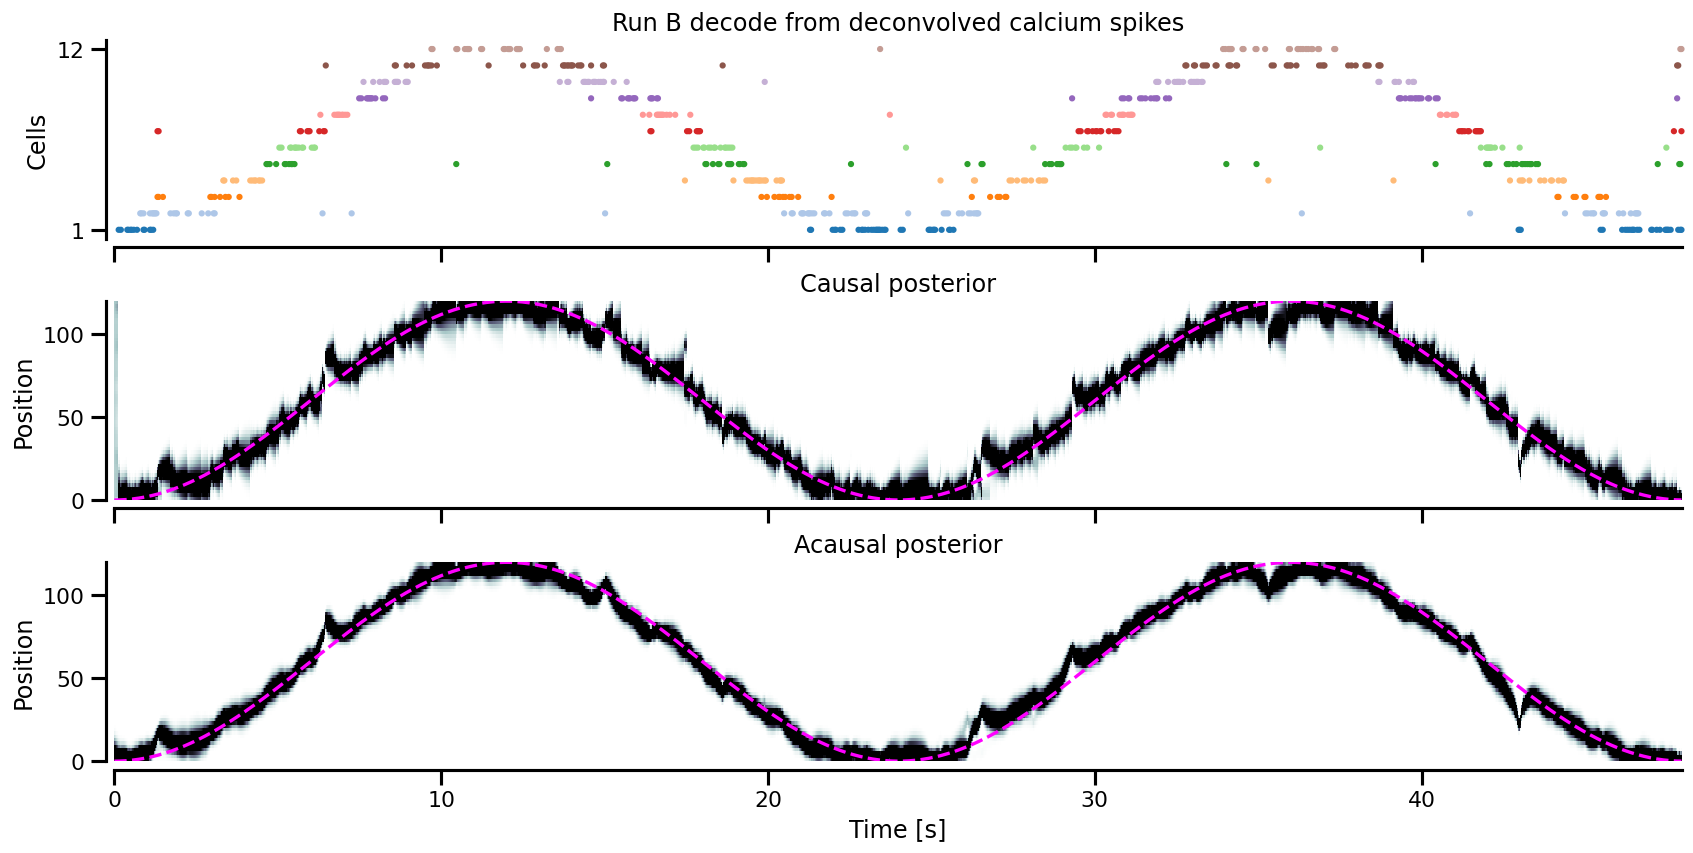

In [11]:
plot_baseline_decode(
    run_b,
    run_b_results,
    title="Run B decode from deconvolved calcium spikes",
);

ValueError: x and y must have same first dimension, but have shapes (200,) and (20,)

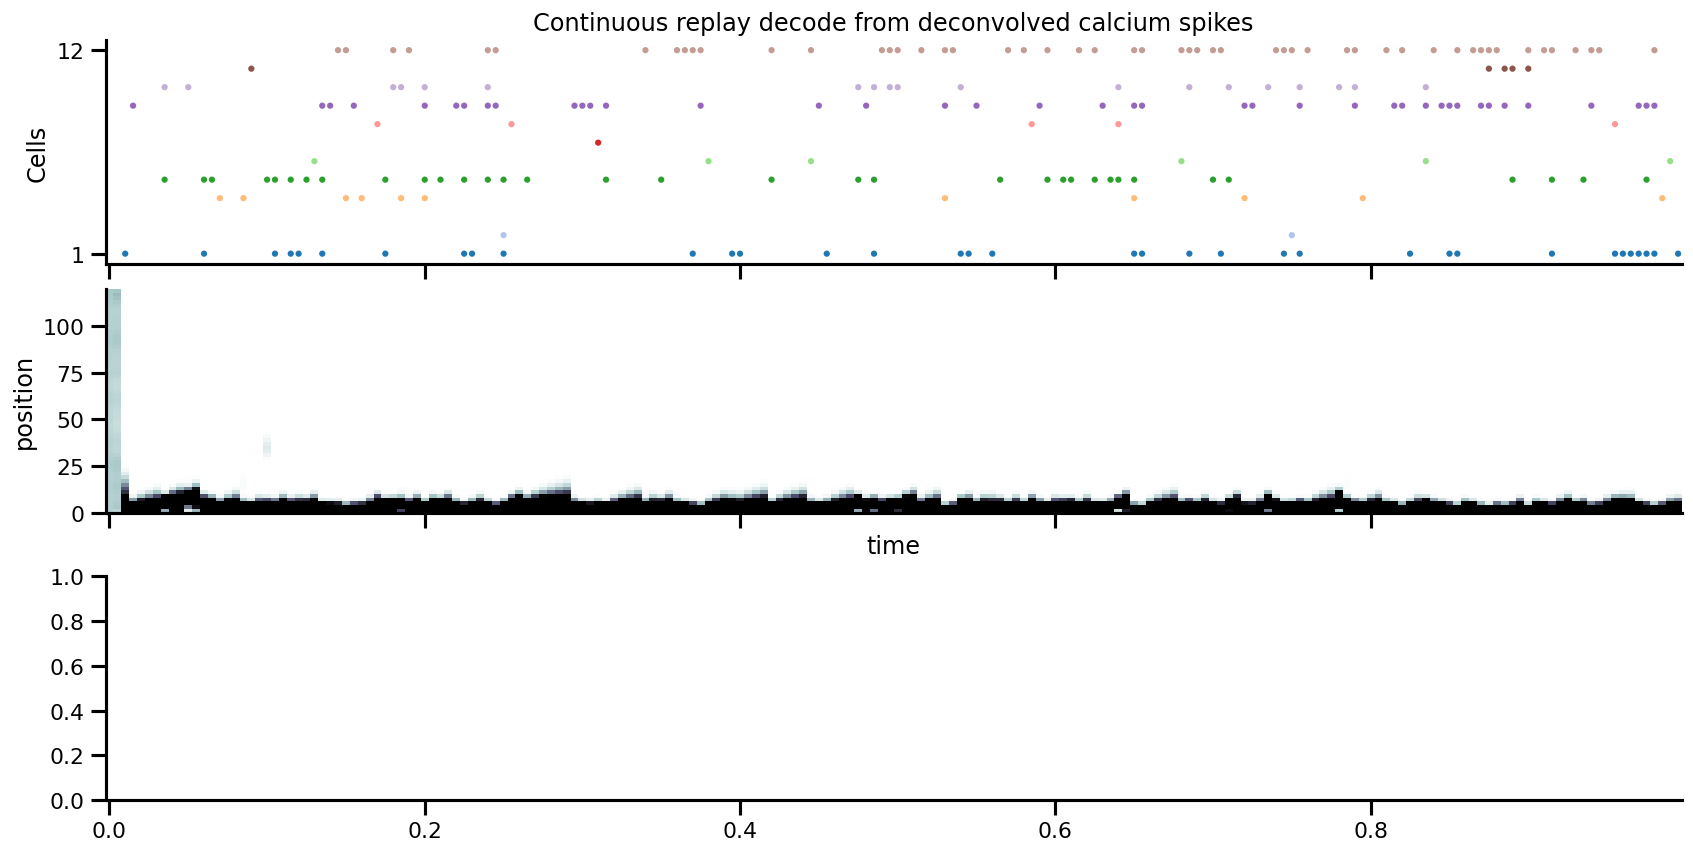

In [12]:
plot_baseline_decode(
    replay_b,
    replay_b_results,
    title="Continuous replay decode from deconvolved calcium spikes",
);

## 2. Noise effect

/home/ericliu/anaconda3/lib/python3.13/site-packages/oasis/functions.py:817: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not `ravel`ed. To preserve the existing behavior and silence this warning, `ravel` arguments before passing them to `toeplitz`.
  A = scipy.linalg.toeplitz(xc[np.arange(lags)],
/home/ericliu/Documents/research_setup/neural_analysis_tool/decode_trajectory_calcium_transient/replay_trajectory_classification/likelihoods/spiking_likelihood_kde.py:148: RuntimeWarning: divide by zero encountered in log
  return np.exp(np.log(mean_rate) + np.log(marginal_density) - np.log(occupancy))


  0%|          | 0/12 [00:00<?, ?it/s]

/home/ericliu/anaconda3/lib/python3.13/site-packages/oasis/functions.py:817: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not `ravel`ed. To preserve the existing behavior and silence this warning, `ravel` arguments before passing them to `toeplitz`.
  A = scipy.linalg.toeplitz(xc[np.arange(lags)],
/home/ericliu/Documents/research_setup/neural_analysis_tool/decode_trajectory_calcium_transient/replay_trajectory_classification/likelihoods/spiking_likelihood_kde.py:148: RuntimeWarning: divide by zero encountered in log
  return np.exp(np.log(mean_rate) + np.log(marginal_density) - np.log(occupancy))


  0%|          | 0/12 [00:00<?, ?it/s]

/home/ericliu/anaconda3/lib/python3.13/site-packages/oasis/functions.py:817: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not `ravel`ed. To preserve the existing behavior and silence this warning, `ravel` arguments before passing them to `toeplitz`.
  A = scipy.linalg.toeplitz(xc[np.arange(lags)],
/home/ericliu/Documents/research_setup/neural_analysis_tool/decode_trajectory_calcium_transient/replay_trajectory_classification/likelihoods/spiking_likelihood_kde.py:148: RuntimeWarning: divide by zero encountered in log
  return np.exp(np.log(mean_rate) + np.log(marginal_density) - np.log(occupancy))


  0%|          | 0/12 [00:00<?, ?it/s]

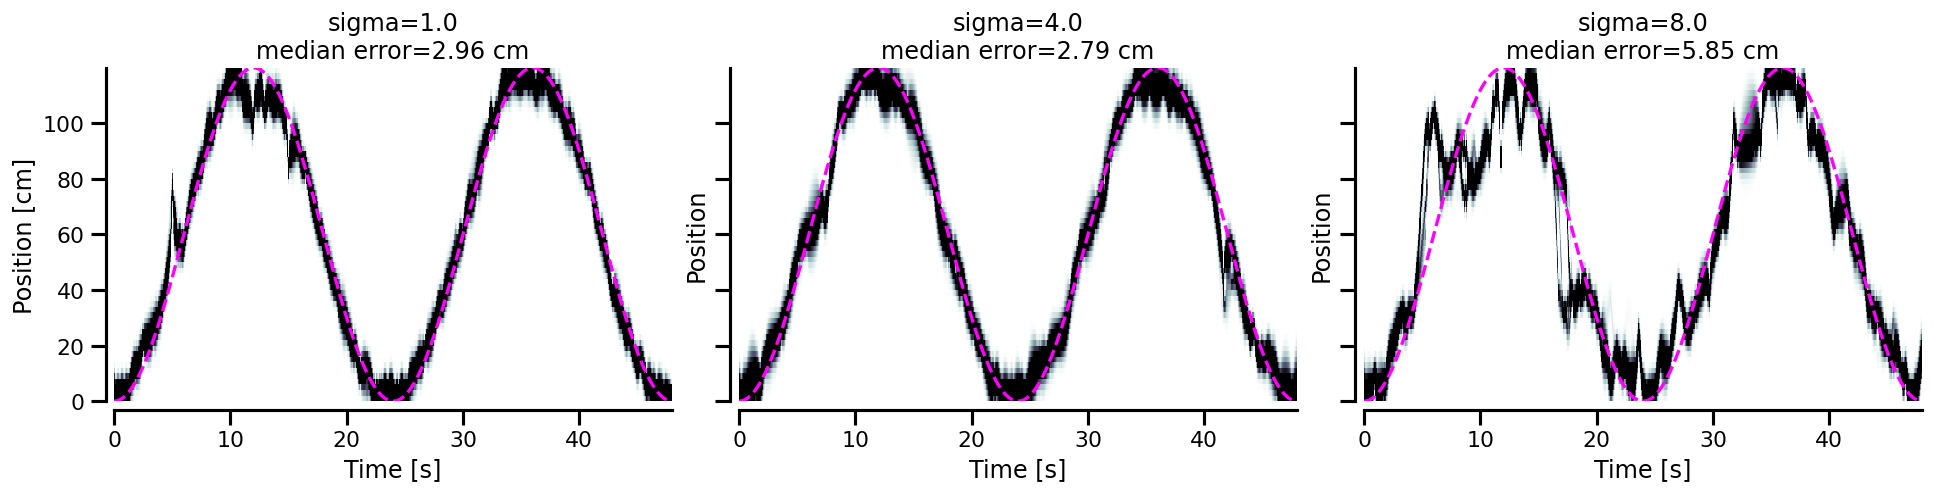

In [ ]:
noise_visual_results = []
for sigma in FIXED_SIGMAS:
    train_dataset = make_run_dataset(rng_seed=100 + int(sigma * 10), sigma=sigma, running_speed=BASE_RUNNING_SPEED)
    test_dataset = make_run_dataset(rng_seed=200 + int(sigma * 10), sigma=sigma, running_speed=BASE_RUNNING_SPEED)
    decoder = fit_decoder(train_dataset)
    results = decode_dataset(decoder, test_dataset)
    error = median_decoding_error(results.acausal_posterior, test_dataset["position"])
    noise_visual_results.append((sigma, test_dataset, results, error))

fig, axes = plt.subplots(1, len(noise_visual_results), figsize=(16, 4), sharey=True, constrained_layout=True)
for ax, (sigma, dataset, results, error) in zip(axes, noise_visual_results):
    plot_overlay_panel(ax, dataset, results, title=f"sigma={sigma:.1f}\nmedian error={error:.2f} cm")
axes[0].set_ylabel("Position [cm]")
sns.despine(offset=5)

In [ ]:
noise_error_rows = []
for sigma in SIGMA_SWEEP:
    train_dataset = make_run_dataset(rng_seed=1000 + int(sigma * 100), sigma=float(sigma), running_speed=BASE_RUNNING_SPEED)
    test_dataset = make_run_dataset(rng_seed=2000 + int(sigma * 100), sigma=float(sigma), running_speed=BASE_RUNNING_SPEED)
    decoder = fit_decoder(train_dataset)
    results = decode_dataset(decoder, test_dataset)
    noise_error_rows.append({
        "sigma": float(sigma),
        "median_abs_error": median_decoding_error(results.acausal_posterior, test_dataset["position"]),
    })

noise_error_df = summarize_errors(noise_error_rows, "sigma")
noise_error_df

/home/ericliu/anaconda3/lib/python3.13/site-packages/oasis/functions.py:817: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not `ravel`ed. To preserve the existing behavior and silence this warning, `ravel` arguments before passing them to `toeplitz`.
  A = scipy.linalg.toeplitz(xc[np.arange(lags)],
/home/ericliu/Documents/research_setup/neural_analysis_tool/decode_trajectory_calcium_transient/replay_trajectory_classification/likelihoods/spiking_likelihood_kde.py:148: RuntimeWarning: divide by zero encountered in log
  return np.exp(np.log(mean_rate) + np.log(marginal_density) - np.log(occupancy))


  0%|          | 0/12 [00:00<?, ?it/s]

/home/ericliu/anaconda3/lib/python3.13/site-packages/oasis/functions.py:817: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not `ravel`ed. To preserve the existing behavior and silence this warning, `ravel` arguments before passing them to `toeplitz`.
  A = scipy.linalg.toeplitz(xc[np.arange(lags)],
/home/ericliu/Documents/research_setup/neural_analysis_tool/decode_trajectory_calcium_transient/replay_trajectory_classification/likelihoods/spiking_likelihood_kde.py:148: RuntimeWarning: divide by zero encountered in log
  return np.exp(np.log(mean_rate) + np.log(marginal_density) - np.log(occupancy))


  0%|          | 0/12 [00:00<?, ?it/s]

/home/ericliu/anaconda3/lib/python3.13/site-packages/oasis/functions.py:817: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not `ravel`ed. To preserve the existing behavior and silence this warning, `ravel` arguments before passing them to `toeplitz`.
  A = scipy.linalg.toeplitz(xc[np.arange(lags)],
/home/ericliu/Documents/research_setup/neural_analysis_tool/decode_trajectory_calcium_transient/replay_trajectory_classification/likelihoods/spiking_likelihood_kde.py:148: RuntimeWarning: divide by zero encountered in log
  return np.exp(np.log(mean_rate) + np.log(marginal_density) - np.log(occupancy))


...

/home/ericliu/anaconda3/lib/python3.13/site-packages/oasis/functions.py:817: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not `ravel`ed. To preserve the existing behavior and silence this warning, `ravel` arguments before passing them to `toeplitz`.
  A = scipy.linalg.toeplitz(xc[np.arange(lags)],
/home/ericliu/Documents/research_setup/neural_analysis_tool/decode_trajectory_calcium_transient/replay_trajectory_classification/likelihoods/spiking_likelihood_kde.py:148: RuntimeWarning: divide by zero encountered in log
  return np.exp(np.log(mean_rate) + np.log(marginal_density) - np.log(occupancy))


  0%|          | 0/12 [00:00<?, ?it/s]

/home/ericliu/anaconda3/lib/python3.13/site-packages/oasis/functions.py:817: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not `ravel`ed. To preserve the existing behavior and silence this warning, `ravel` arguments before passing them to `toeplitz`.
  A = scipy.linalg.toeplitz(xc[np.arange(lags)],


  0%|          | 0/12 [00:00<?, ?it/s]

,sigma,median_abs_error
0,1.0,2.930583
1,2.0,2.977322
2,4.0,2.990633
3,8.0,3.234897
4,10.0,8.542690
5,12.0,4.151073
6,14.0,35.860883
7,16.0,39.730072
8,18.0,34.975070
9,20.0,56.565376


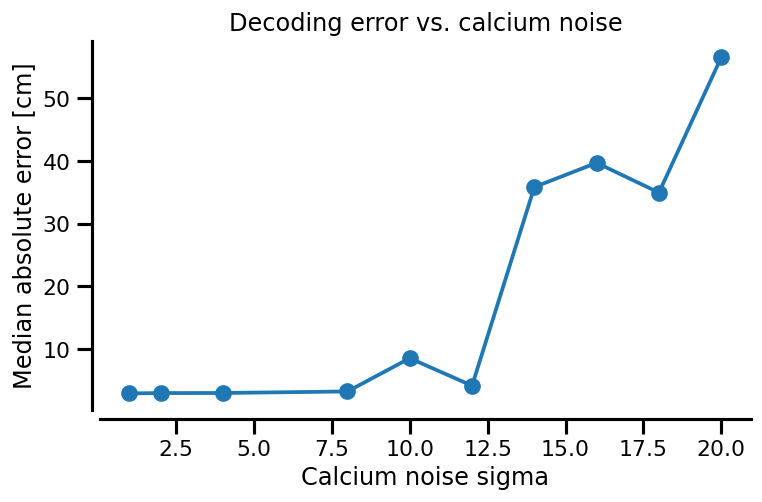

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(noise_error_df["sigma"], noise_error_df["median_abs_error"], marker="o")
plt.xlabel("Calcium noise sigma")
plt.ylabel("Median absolute error [cm]")
plt.title("Decoding error vs. calcium noise")
sns.despine(offset=5)

## 3. Speed effect

/home/ericliu/anaconda3/lib/python3.13/site-packages/oasis/functions.py:817: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not `ravel`ed. To preserve the existing behavior and silence this warning, `ravel` arguments before passing them to `toeplitz`.
  A = scipy.linalg.toeplitz(xc[np.arange(lags)],
/home/ericliu/Documents/research_setup/neural_analysis_tool/decode_trajectory_calcium_transient/replay_trajectory_classification/likelihoods/spiking_likelihood_kde.py:148: RuntimeWarning: divide by zero encountered in log
  return np.exp(np.log(mean_rate) + np.log(marginal_density) - np.log(occupancy))


  0%|          | 0/12 [00:00<?, ?it/s]

/home/ericliu/anaconda3/lib/python3.13/site-packages/oasis/functions.py:817: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not `ravel`ed. To preserve the existing behavior and silence this warning, `ravel` arguments before passing them to `toeplitz`.
  A = scipy.linalg.toeplitz(xc[np.arange(lags)],
/home/ericliu/Documents/research_setup/neural_analysis_tool/decode_trajectory_calcium_transient/replay_trajectory_classification/likelihoods/spiking_likelihood_kde.py:148: RuntimeWarning: divide by zero encountered in log
  return np.exp(np.log(mean_rate) + np.log(marginal_density) - np.log(occupancy))


  0%|          | 0/12 [00:00<?, ?it/s]

/home/ericliu/anaconda3/lib/python3.13/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 242, using nperseg = 242
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/home/ericliu/anaconda3/lib/python3.13/site-packages/oasis/functions.py:817: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not `ravel`ed. To preserve the existing behavior and silence this warning, `ravel` arguments before passing them to `toeplitz`.
  A = scipy.linalg.toeplitz(xc[np.arange(lags)],
/home/ericliu/Documents/research_setup/neural_analysis_tool/decode_trajectory_calcium_transient/replay_trajectory_classification/likelihoods/spiking_likelihood_kde.py:148: RuntimeWarning: divide by zero encountered in log
  return np.exp(np.log(mean_rate) + np.log(marginal_density) - np.log(occupancy))


  0%|          | 0/12 [00:00<?, ?it/s]

/home/ericliu/anaconda3/lib/python3.13/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 161, using nperseg = 161
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/home/ericliu/anaconda3/lib/python3.13/site-packages/oasis/functions.py:817: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not `ravel`ed. To preserve the existing behavior and silence this warning, `ravel` arguments before passing them to `toeplitz`.
  A = scipy.linalg.toeplitz(xc[np.arange(lags)],
/home/ericliu/Documents/research_setup/neural_analysis_tool/decode_trajectory_calcium_transient/replay_trajectory_classification/likelihoods/spiking_likelihood_kde.py:148: RuntimeWarning: divide by zero encountered in log
  return np.exp(np.log(mean_rate) + np.log(marginal_density) - np.log(occupancy))


  0%|          | 0/12 [00:00<?, ?it/s]

/home/ericliu/anaconda3/lib/python3.13/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 121, using nperseg = 121
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/home/ericliu/anaconda3/lib/python3.13/site-packages/oasis/functions.py:817: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not `ravel`ed. To preserve the existing behavior and silence this warning, `ravel` arguments before passing them to `toeplitz`.
  A = scipy.linalg.toeplitz(xc[np.arange(lags)],
/home/ericliu/Documents/research_setup/neural_analysis_tool/decode_trajectory_calcium_transient/replay_trajectory_classification/likelihoods/spiking_likelihood_kde.py:148: RuntimeWarning: divide by zero encountered in log
  return np.exp(np.log(mean_rate) + np.log(marginal_density) - np.log(occupancy))


  0%|          | 0/12 [00:00<?, ?it/s]

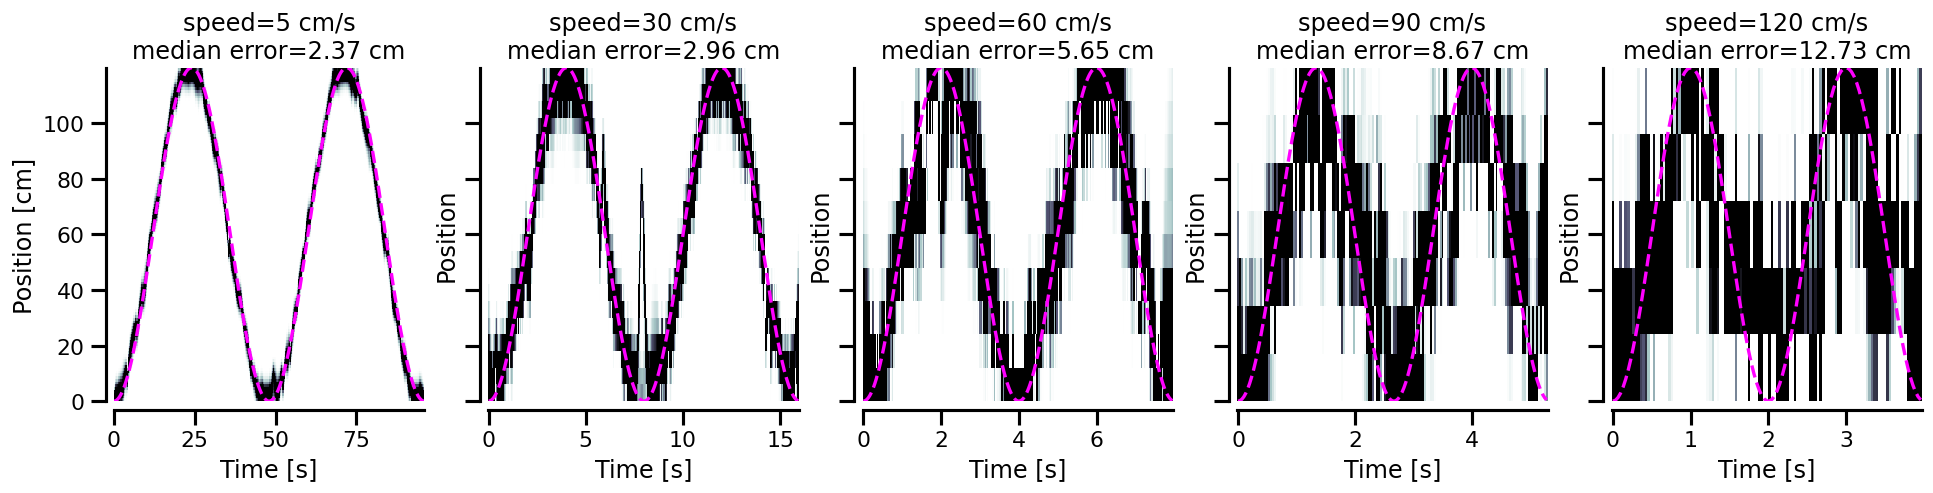

In [ ]:
speed_results = []
for running_speed in SPEED_VALUES:
    train_dataset = make_run_dataset(rng_seed=300 + int(running_speed), sigma=BASE_SIGMA, running_speed=running_speed)
    test_dataset = make_run_dataset(rng_seed=400 + int(running_speed), sigma=BASE_SIGMA, running_speed=running_speed)
    decoder = fit_decoder(train_dataset)
    results = decode_dataset(decoder, test_dataset)
    error = median_decoding_error(results.acausal_posterior, test_dataset["position"])
    speed_results.append((running_speed, test_dataset, results, error))

fig, axes = plt.subplots(1, len(speed_results), figsize=(16, 4), sharey=True, constrained_layout=True)
for ax, (running_speed, dataset, results, error) in zip(axes, speed_results):
    plot_overlay_panel(ax, dataset, results, title=f"speed={running_speed:.0f} cm/s\nmedian error={error:.2f} cm")
axes[0].set_ylabel("Position [cm]")
sns.despine(offset=5)

In [ ]:
speed_error_df = summarize_errors(
    [
        {"running_speed": running_speed, "median_abs_error": error}
        for running_speed, _dataset, _results, error in speed_results
    ],
    "running_speed",
)
speed_error_df

,running_speed,median_abs_error
0,5.0,2.370408
1,30.0,2.962484
2,60.0,5.648463
3,90.0,8.670843
4,120.0,12.730487
